# 2b · Feature exploration

Sanity-checks the features built in `2_feature_engineer.ipynb` before they go into `3_split.ipynb` /
`4_normalize.ipynb`. Train-split only (features files have no split column, so we join it in from
`data/processed` M15 and as-of merge onto slower TFs) — correlation/signal numbers must never be
computed on val/test, or conclusions drawn here leak into feature-selection decisions.

Checks:
1. Intra-TF correlation heatmap — flag redundant feature pairs
2. Feature vs forward-return correlation — rough signal strength per feature
3. Distribution / outlier scan — anything blown up or degenerate
4. Cross-TF redundancy — e.g. D1 `ema_regime` vs H4 `ema_trend` agreement

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.settings import DATA_FEATURES, DATA_PROCESSED

SYMBOL = "GBPUSD"
TIMEFRAMES = ["D1", "H4", "H1", "M15"]

sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 8)})

## Load features + attach train/val/test split (train only kept for analysis)

In [2]:
m15_proc = pd.read_parquet(DATA_PROCESSED / f"{SYMBOL}_M15.parquet")[["datetime", "split", "close"]]

feat = {tf: pd.read_parquet(DATA_FEATURES / f"{SYMBOL}_{tf}_features.parquet") for tf in TIMEFRAMES}

# as-of join each TF's own datetime to the M15 split label (last closed bar <= t), train rows only
train_feat = {}
for tf in TIMEFRAMES:
    df = feat[tf].sort_values("datetime")
    merged = pd.merge_asof(df, m15_proc[["datetime", "split"]], on="datetime", direction="backward")
    train_feat[tf] = merged[merged["split"] == "train"].drop(columns="split").dropna().reset_index(drop=True)
    print(f"{tf}: {len(train_feat[tf])} train rows (post-dropna, post-warmup)")

D1: 2664 train rows (post-dropna, post-warmup)
H4: 17119 train rows (post-dropna, post-warmup)
H1: 68410 train rows (post-dropna, post-warmup)
M15: 269904 train rows (post-dropna, post-warmup)


## 1 · Intra-TF correlation heatmaps

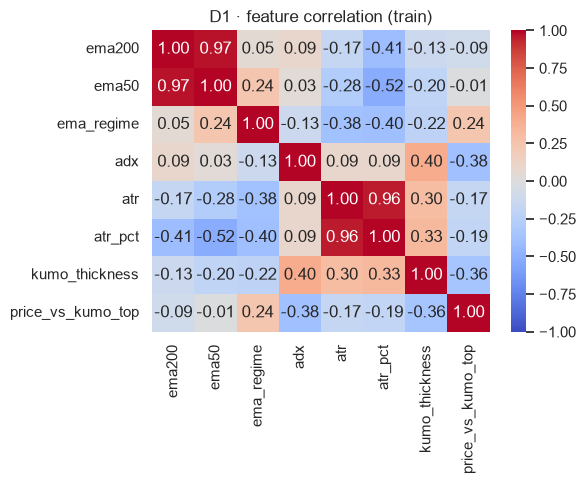

[D1] pairs with |corr| >= 0.9:
feature_a feature_b     corr
   ema200     ema50 0.972375
      atr   atr_pct 0.955549


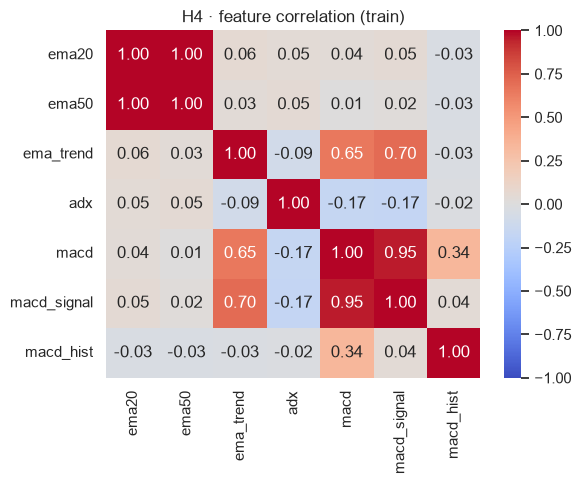

[H4] pairs with |corr| >= 0.9:
feature_a   feature_b     corr
    ema20       ema50 0.999283
     macd macd_signal 0.953607


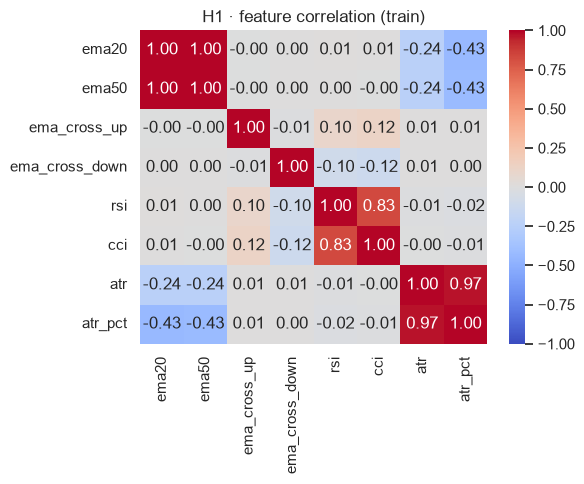

[H1] pairs with |corr| >= 0.9:
feature_a feature_b     corr
    ema20     ema50 0.999810
      atr   atr_pct 0.971922


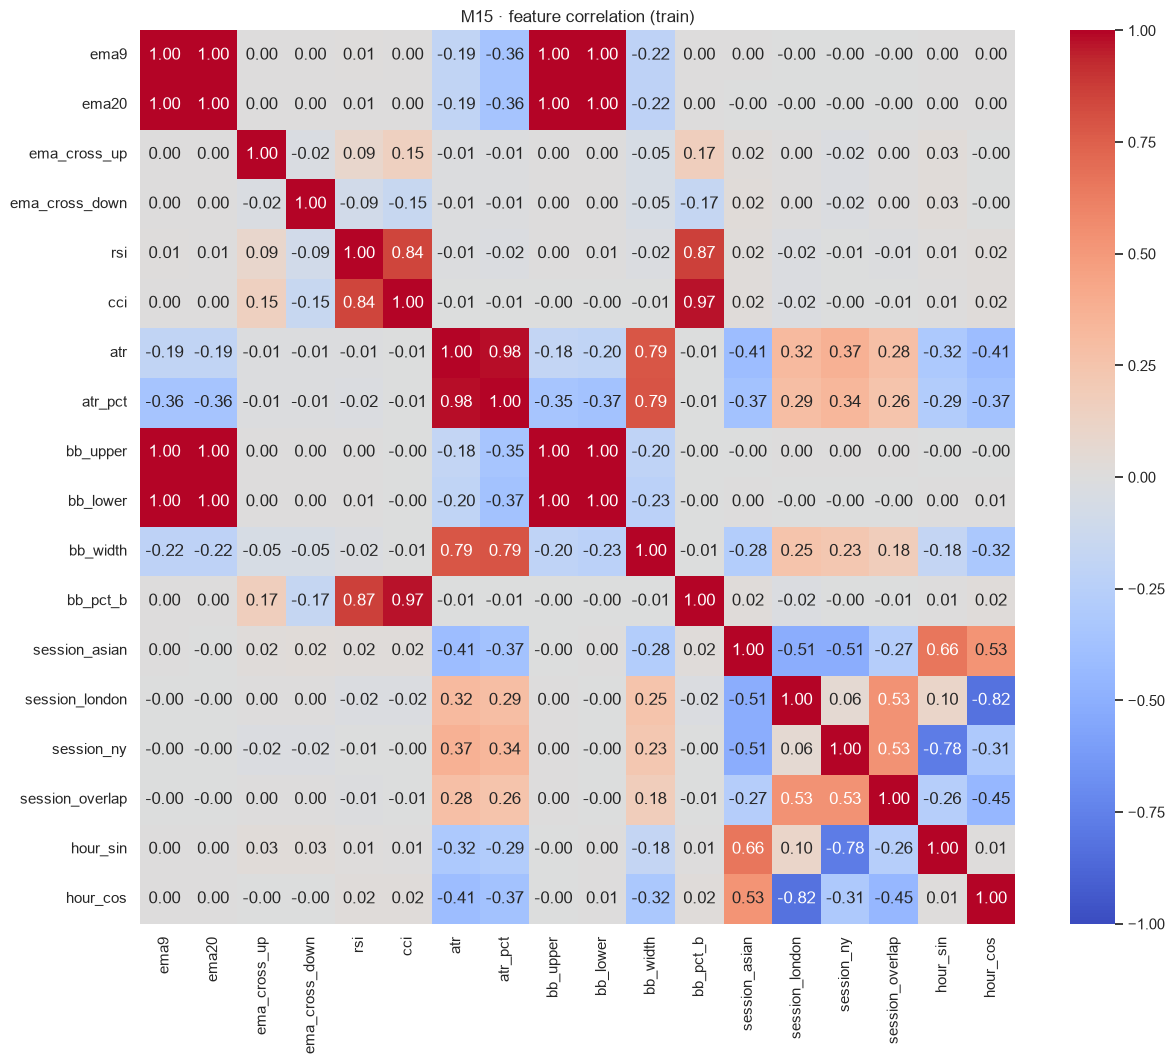

[M15] pairs with |corr| >= 0.9:
feature_a feature_b     corr
     ema9     ema20 0.999985
    ema20  bb_lower 0.999908
    ema20  bb_upper 0.999906
     ema9  bb_lower 0.999893
     ema9  bb_upper 0.999874
 bb_upper  bb_lower 0.999646
      atr   atr_pct 0.977967
      cci  bb_pct_b 0.974609


In [3]:
def plot_corr(df: pd.DataFrame, tf: str, threshold: float = 0.9):
    cols = [c for c in df.columns if c != "datetime"]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(max(6, len(cols) * 0.7), max(5, len(cols) * 0.6)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"{tf} · feature correlation (train)")
    plt.tight_layout()
    plt.show()

    # flag redundant pairs above threshold (excluding diagonal)
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    flagged = pairs[pairs["corr"].abs() >= threshold].sort_values("corr", key=abs, ascending=False)
    if len(flagged):
        print(f"[{tf}] pairs with |corr| >= {threshold}:")
        print(flagged.to_string(index=False))
    else:
        print(f"[{tf}] no pairs above |corr| >= {threshold}")
    return corr


corrs = {}
for tf in TIMEFRAMES:
    corrs[tf] = plot_corr(train_feat[tf], tf)

## 2 · Feature vs forward-return correlation (rough signal check)

Forward return computed on M15 close only (label for analysis, never fed to the model). Each TF's
features are as-of merged onto the M15 grid first, so slower TFs get their value repeated across
the M15 bars it was valid for (correctly lagged, matches what the agent actually sees).

In [4]:
FWD_HORIZONS = [1, 4, 16]  # in M15 bars: 15m, 1h, 4h ahead

m15_train = m15_proc[m15_proc["split"] == "train"].sort_values("datetime").reset_index(drop=True)
for h in FWD_HORIZONS:
    m15_train[f"fwd_ret_{h}"] = m15_train["close"].shift(-h) / m15_train["close"] - 1

signal_rows = []
for tf in TIMEFRAMES:
    df = feat[tf].sort_values("datetime")
    merged = pd.merge_asof(m15_train, df, on="datetime", direction="backward")
    feature_cols = [c for c in df.columns if c != "datetime"]
    for col in feature_cols:
        for h in FWD_HORIZONS:
            valid = merged[[col, f"fwd_ret_{h}"]].dropna()
            if len(valid) < 100:
                continue
            c = valid[col].corr(valid[f"fwd_ret_{h}"])
            signal_rows.append({"tf": tf, "feature": col, "horizon_bars": h, "corr_fwd_ret": c})

signal_df = pd.DataFrame(signal_rows)
signal_pivot = signal_df.pivot(index=["tf", "feature"], columns="horizon_bars", values="corr_fwd_ret")
signal_pivot["max_abs"] = signal_pivot.abs().max(axis=1)
signal_pivot.sort_values("max_abs", ascending=False)

horizon_bars                  1         4        16   max_abs
tf  feature                                                  
H1  rsi                0.115241  0.120930  0.064862  0.120930
    cci                0.109151  0.109794  0.059456  0.109794
D1  price_vs_kumo_top  0.027686  0.055685  0.108350  0.108350
H4  macd_hist          0.043356  0.079687  0.099313  0.099313
    macd               0.015187  0.027611  0.031864  0.031864
H1  ema_cross_down    -0.028199 -0.029845 -0.013502  0.029845
H4  adx               -0.005915 -0.011854 -0.023079  0.023079
H1  ema_cross_up       0.020579  0.021646  0.010141  0.021646
M15 bb_pct_b          -0.013763 -0.010878 -0.005160  0.013763
    hour_sin          -0.002269 -0.005461 -0.012664  0.012664
H1  atr               -0.005027 -0.008201 -0.011437  0.011437
M15 rsi               -0.010510 -0.005789  0.001880  0.010510
    bb_width          -0.006987 -0.010452  0.005105  0.010452
D1  ema200            -0.002504 -0.005062 -0.009976  0.009976
M15 ema9              -0.002403 -0.004863 -0.009733  0.009733
    bb_upper          -0.002558 -0.005124 -0.009721  0.009721
    ema20             -0.002414 -0.004889 -0.009707  0.009707
    bb_lower          -0.002316 -0.004743 -0.009696  0.009696
H1  ema50             -0.002279 -0.004752 -0.009628  0.009628
H4  ema50             -0.002249 -0.004589 -0.009354  0.009354
H1  ema20             -0.002018 -0.004433 -0.009295  0.009295
H4  ema20             -0.001977 -0.004085 -0.008771  0.008771
D1  kumo_thickness     0.002180  0.004366  0.008762  0.008762
M15 session_overlap    0.001466  0.003361  0.008702  0.008702
D1  ema50             -0.002113 -0.004278 -0.008462  0.008462
M15 cci               -0.008418 -0.008439 -0.004150  0.008439
H4  ema_trend          0.004709  0.008425  0.008232  0.008425
M15 atr               -0.004983 -0.007694 -0.000939  0.007694
D1  adx               -0.001899 -0.003817 -0.007515  0.007515
M15 session_ny         0.001681  0.002187  0.006580  0.006580
    ema_cross_up      -0.002789 -0.006383 -0.001862  0.006383
    ema_cross_down     0.006297  0.004179  0.000677  0.006297
    atr_pct           -0.002707 -0.003478  0.006053  0.006053
D1  atr                0.001365  0.002877  0.005950  0.005950
H1  atr_pct           -0.004055 -0.004991 -0.003985  0.004991
M15 session_asian     -0.000099  0.000139 -0.004857  0.004857
    session_london    -0.003277 -0.004749 -0.001535  0.004749
    hour_cos           0.002406  0.004631  0.004077  0.004631
H4  macd_signal        0.002281  0.003871  0.002120  0.003871
D1  atr_pct            0.000530  0.001208  0.002933  0.002933
    ema_regime         0.000679  0.001356  0.002680  0.002680

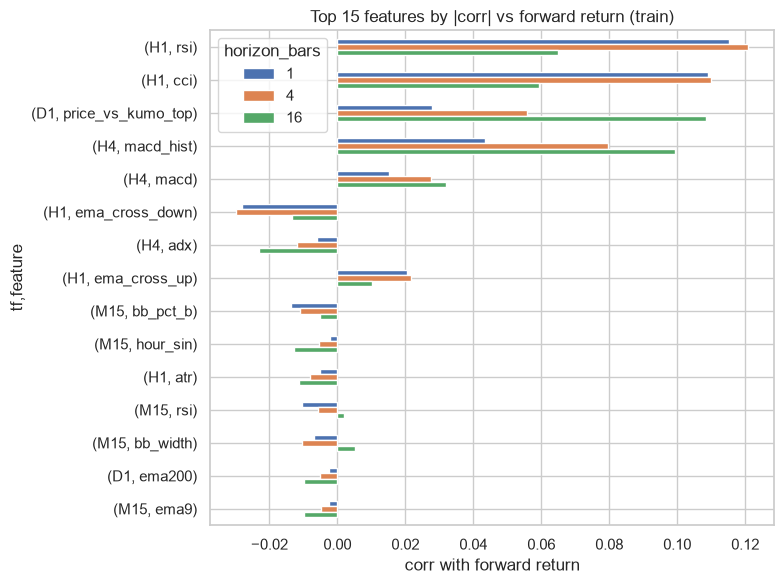

In [5]:
top_n = 15
top_features = signal_pivot.sort_values("max_abs", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.4)))
top_features.drop(columns="max_abs").plot.barh(ax=ax)
ax.set_xlabel("corr with forward return")
ax.set_title(f"Top {top_n} features by |corr| vs forward return (train)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3 · Distribution / outlier scan

Looks for degenerate columns (near-zero variance), extreme skew, or fat-tail blowups that would
dominate robust scaling in step 4.

In [6]:
def describe_tf(df: pd.DataFrame, tf: str) -> pd.DataFrame:
    cols = [c for c in df.columns if c != "datetime"]
    desc = df[cols].agg(["mean", "std", "min", "max", "skew"]).T
    desc["pct99_over_pct1"] = df[cols].quantile(0.99) / df[cols].quantile(0.01).replace(0, np.nan)
    desc["near_constant"] = desc["std"].abs() < 1e-8
    desc.insert(0, "tf", tf)
    return desc


desc_all = pd.concat([describe_tf(train_feat[tf], tf) for tf in TIMEFRAMES])
desc_all

,tf,mean,std,min,max,skew,pct99_over_pct1,near_constant
ema200,D1,1.407423e+00,0.134000,1.210207,1.664073,0.508804,1.371677,False
ema50,D1,1.397467e+00,0.141958,1.142057,1.698645,0.495524,1.470126,False
ema_regime,D1,-2.139640e-01,0.977025,-1.000000,1.000000,0.438320,-1.000000,False
adx,D1,2.401363e+01,9.537866,7.729769,57.467213,0.991505,5.759861,False
atr,D1,1.124761e-02,0.003049,0.005771,0.028473,1.695199,3.609206,False
atr_pct,D1,8.226203e-03,0.002692,0.003437,0.021531,1.787871,5.057334,False
kumo_thickness,D1,1.054281e-02,0.008845,0.000000,0.063605,2.244233,331.757087,False
price_vs_kumo_top,D1,-6.676768e-03,0.016256,-0.079767,0.035306,-0.873874,-0.406367,False
ema20,H4,1.406536e+00,0.147027,1.081736,1.714303,0.315268,1.485957,False
ema50,H4,1.406826e+00,0.146717,1.100633,1.712112,0.316274,1.485748,False


In [7]:
flagged_const = desc_all[desc_all["near_constant"]]
flagged_skew = desc_all[desc_all["skew"].abs() > 5]

print("near-constant columns (candidates to drop):")
print(flagged_const[["tf", "std"]] if len(flagged_const) else "none")
print()
print("heavily skewed columns (|skew| > 5, check robust scaling handles these):")
print(flagged_skew[["tf", "skew"]] if len(flagged_skew) else "none")

near-constant columns (candidates to drop):
none

heavily skewed columns (|skew| > 5, check robust scaling handles these):
                 tf       skew
ema_cross_up     H1  10.309949
ema_cross_down   H1  10.318425
atr              H1   5.652650
ema_cross_up    M15   6.248704
ema_cross_down  M15   6.249227
bb_width        M15   7.892299


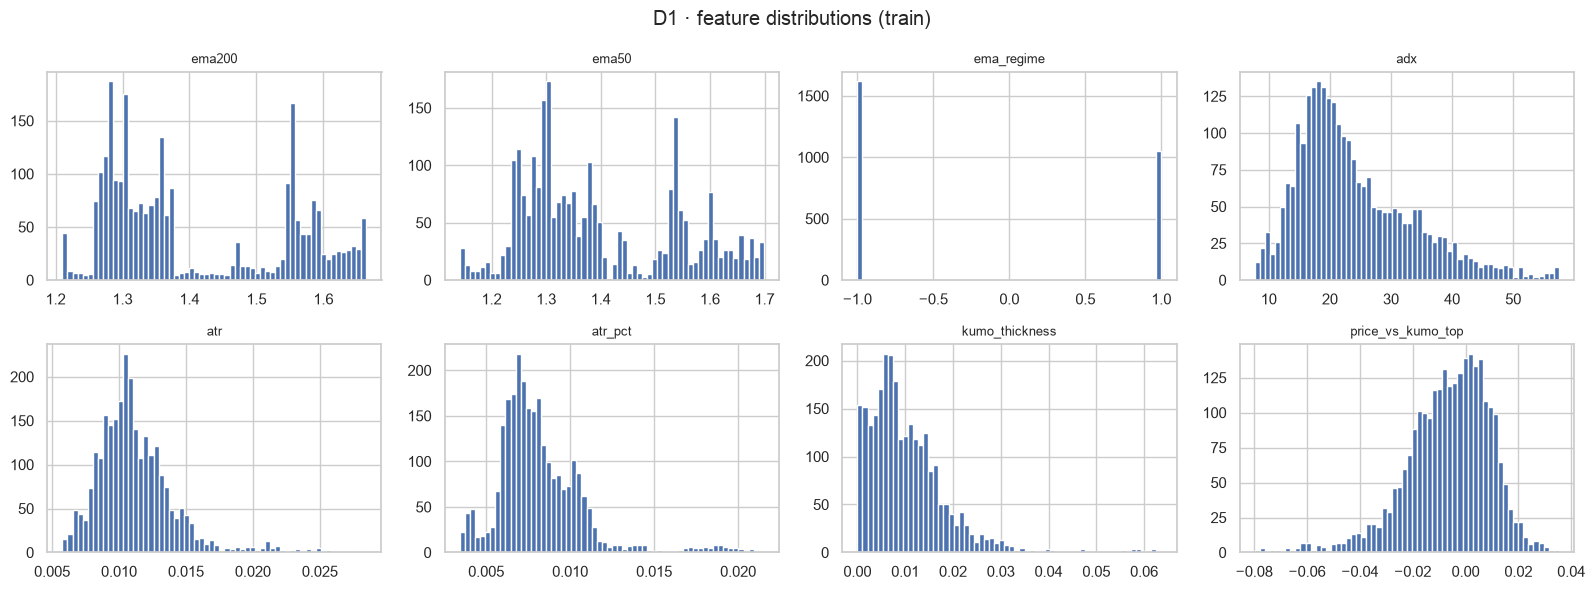

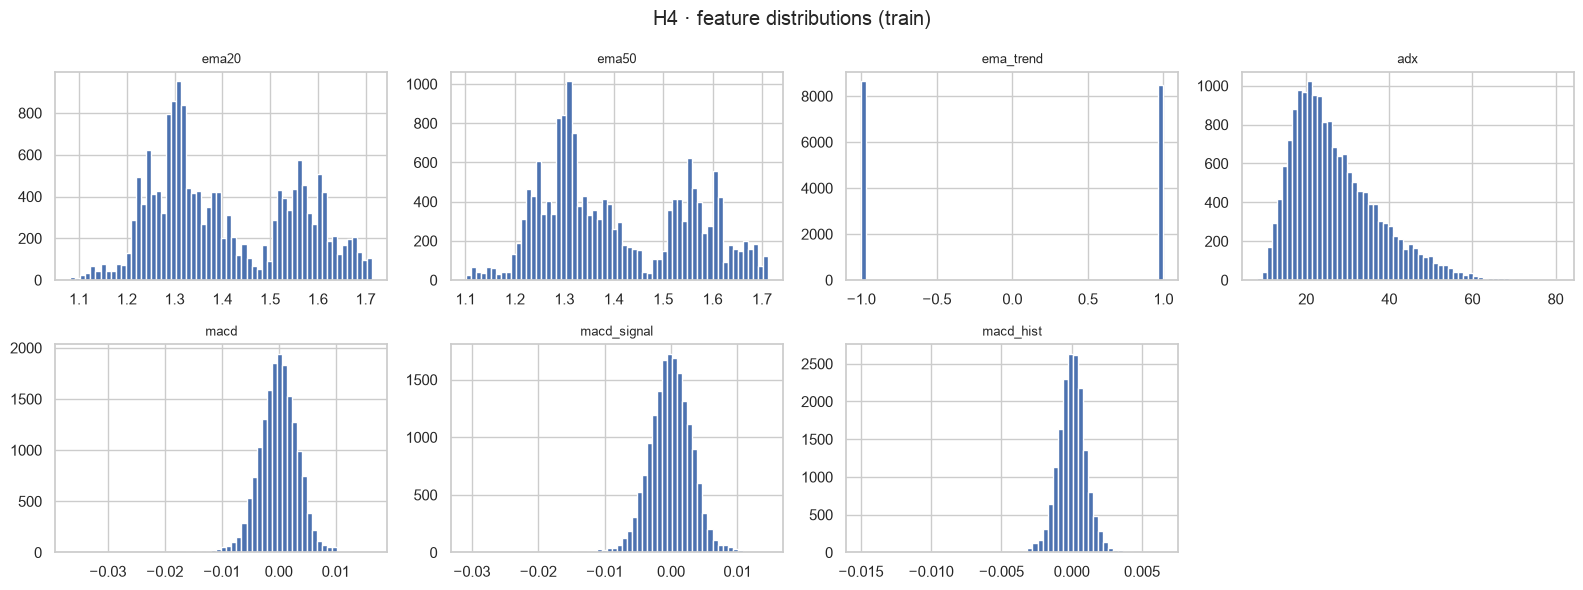

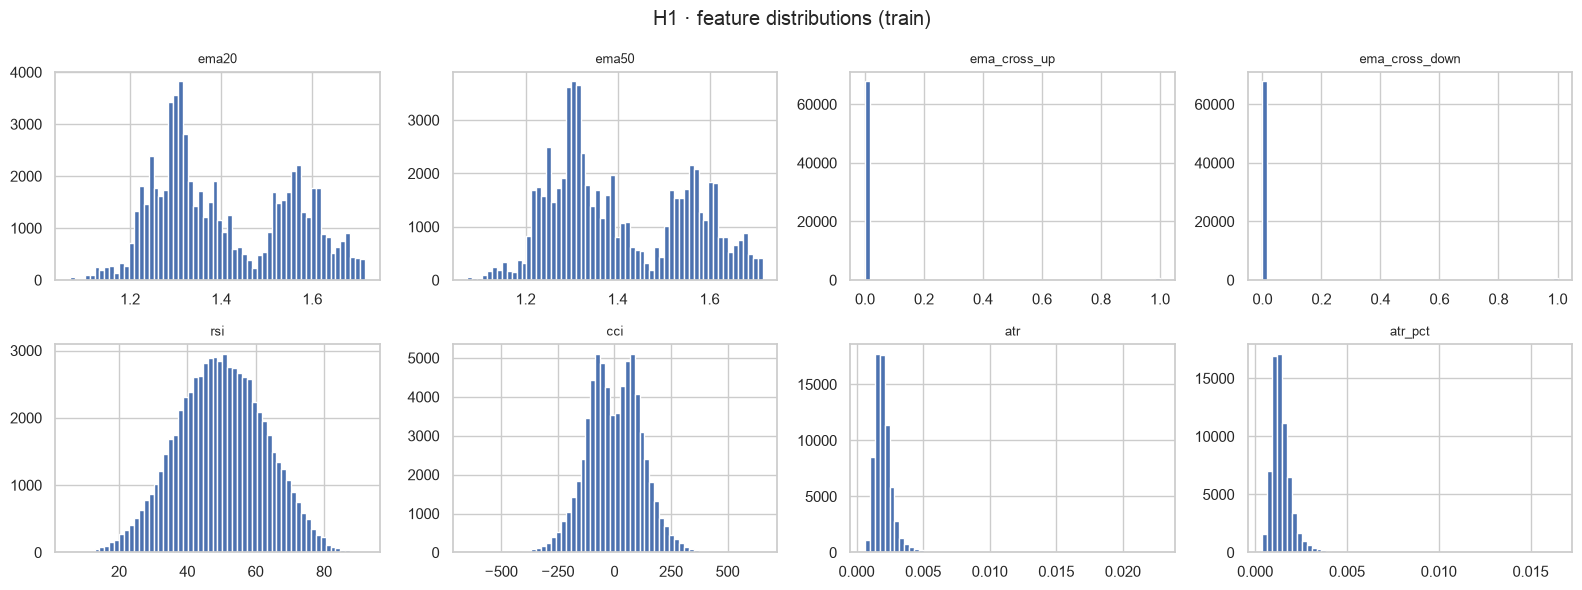

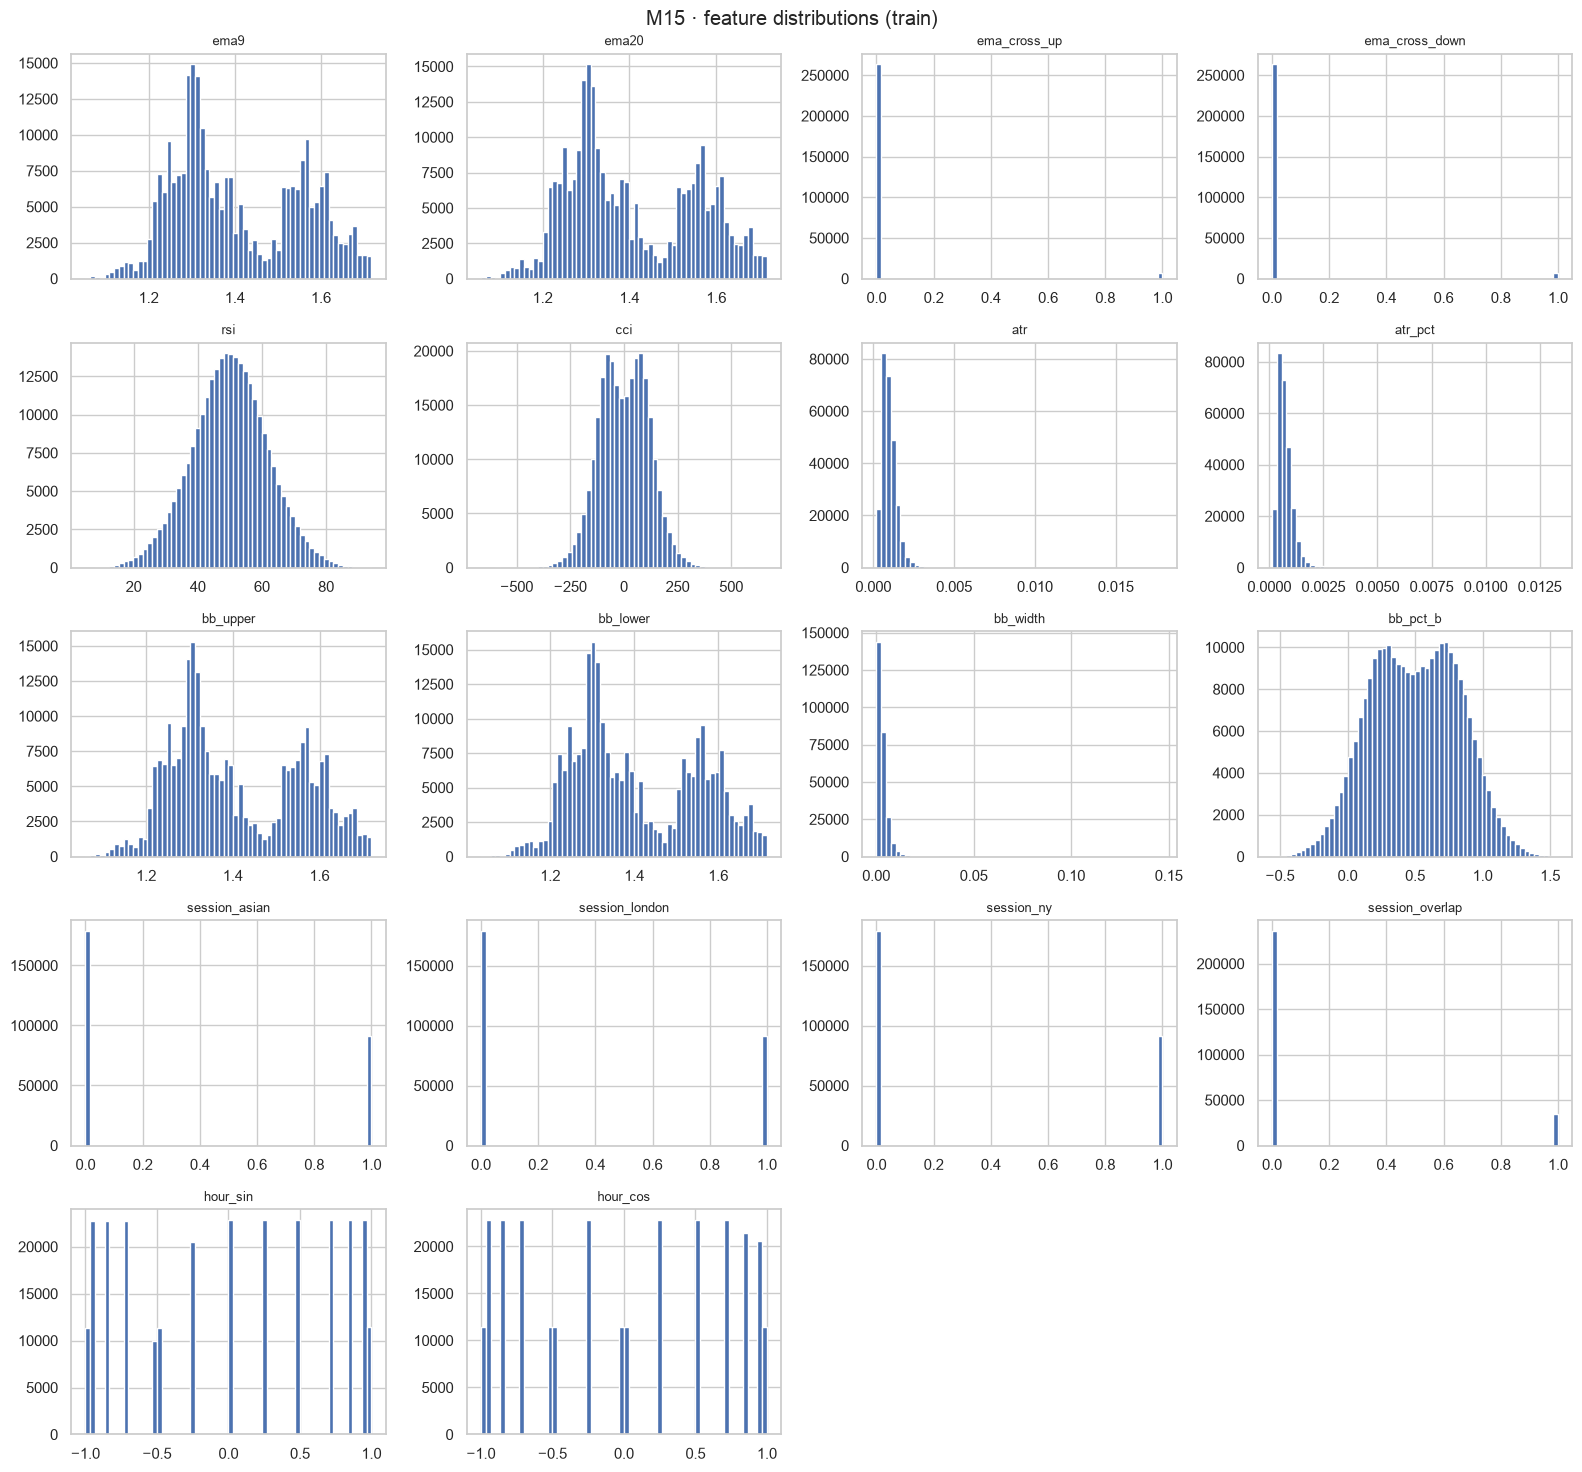

In [8]:
for tf in TIMEFRAMES:
    cols = [c for c in train_feat[tf].columns if c != "datetime"]
    n = len(cols)
    fig, axes = plt.subplots((n + 3) // 4, 4, figsize=(16, 3 * ((n + 3) // 4)))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, cols):
        train_feat[tf][col].hist(bins=60, ax=ax)
        ax.set_title(col, fontsize=9)
    for ax in axes[len(cols):]:
        ax.axis("off")
    fig.suptitle(f"{tf} · feature distributions (train)")
    plt.tight_layout()
    plt.show()

## 4 · Cross-TF redundancy

Regime/trend columns exist on more than one TF (D1 `ema_regime`, H4 `ema_trend`). Check how often
they agree — high agreement means one may be redundant given the other, low agreement means each
carries distinct information worth keeping both.

In [9]:
d1 = feat["D1"][["datetime", "ema_regime"]].sort_values("datetime")
h4 = feat["H4"][["datetime", "ema_trend"]].sort_values("datetime")

cross = pd.merge_asof(h4, d1, on="datetime", direction="backward").dropna()
cross = pd.merge_asof(cross, m15_proc[["datetime", "split"]], on="datetime", direction="backward")
cross_train = cross[cross["split"] == "train"]

agree_rate = (cross_train["ema_regime"] == cross_train["ema_trend"]).mean()
print(f"D1 ema_regime vs H4 ema_trend agreement (train): {agree_rate:.1%}")
pd.crosstab(cross_train["ema_regime"], cross_train["ema_trend"], normalize=True)

D1 ema_regime vs H4 ema_trend agreement (train): 54.5%


ema_trend,-1.0,1.0
ema_regime,,
-1.0,0.332353,0.274759
1.0,0.180356,0.212533


## Summary

Fill in after running: which features to drop (redundant / near-constant / no signal), which to
keep an eye on (heavy skew, low agreement across TFs worth exploiting rather than dropping).